This one plots different files to visualize the salinity at high and low water slack across different distances with 3km increment from the mouth of the estuaries Dinh An and Tran De

In [72]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


PROJECT_ROOT = Path.cwd().parent

data_folder = (
    PROJECT_ROOT
    / "Data"
    / "Processed"
    / "Salinity measurements 2016"
)

# Find all cleaned CSV files
csv_files = list(data_folder.glob("*_cleaned.csv"))

print(f"Found {len(csv_files)} files")

Found 10 files


In [73]:
# This function plots a heatmap per one data file
def plot_salinity_heatmap(file_path, ax):

    # Read data
    df = pd.read_csv(file_path)

    # Reshape for heatmap
    salinity_matrix = df.pivot(
        index="depth_m",
        columns="distance_km",
        values="salinity_pss"
    )

    # Extract metadata from filename
    parts = file_path.stem.split("_")

    tidal = parts[1].upper()
    date_string = parts[3][:8]

    date = pd.to_datetime(
        date_string,
        format="%Y%m%d"
    )

    # Plot
    image = ax.imshow(
        salinity_matrix,
        aspect="auto",
        origin="upper",
        extent=[
            salinity_matrix.columns.min(),
            salinity_matrix.columns.max(),
            salinity_matrix.index.max(),
            salinity_matrix.index.min()
        ],
        vmin=0,
        vmax=30
    )

    ax.set_title(
        f"{date.strftime('%d %b %Y')} – {tidal}"
    )

    ax.set_xlabel("Distance upstream (km)")
    ax.set_ylabel("Depth (m)")

    return image

In [74]:
# Separate plots by measuring location Dinh An and Tran De
dinh_an_files = [file for file in csv_files if "_da_" in file.name]

tran_de_files = [file for file in csv_files if "_td_" in file.name]

In [75]:
# This function plots subplots for each location
def plot_location(files, location_name):

    fig, axes = plt.subplots(2,3,figsize=(16, 9))

    axes = axes.flatten()

    for ax, file_path in zip(axes, files):
        image = plot_salinity_heatmap(file_path, ax)

    # Hide unused subplot
    for ax in axes[len(files):]:
        ax.set_visible(False)

    fig.suptitle(
        f"Salinity Profiles – {location_name}",
        fontsize=16
    )

    # One colorbar shared by all heatmaps
    fig.colorbar(image,ax=axes.tolist(),label="Salinity (PSS)",shrink=0.8)

    plt.show()

Subplots for Dinh An's salinity

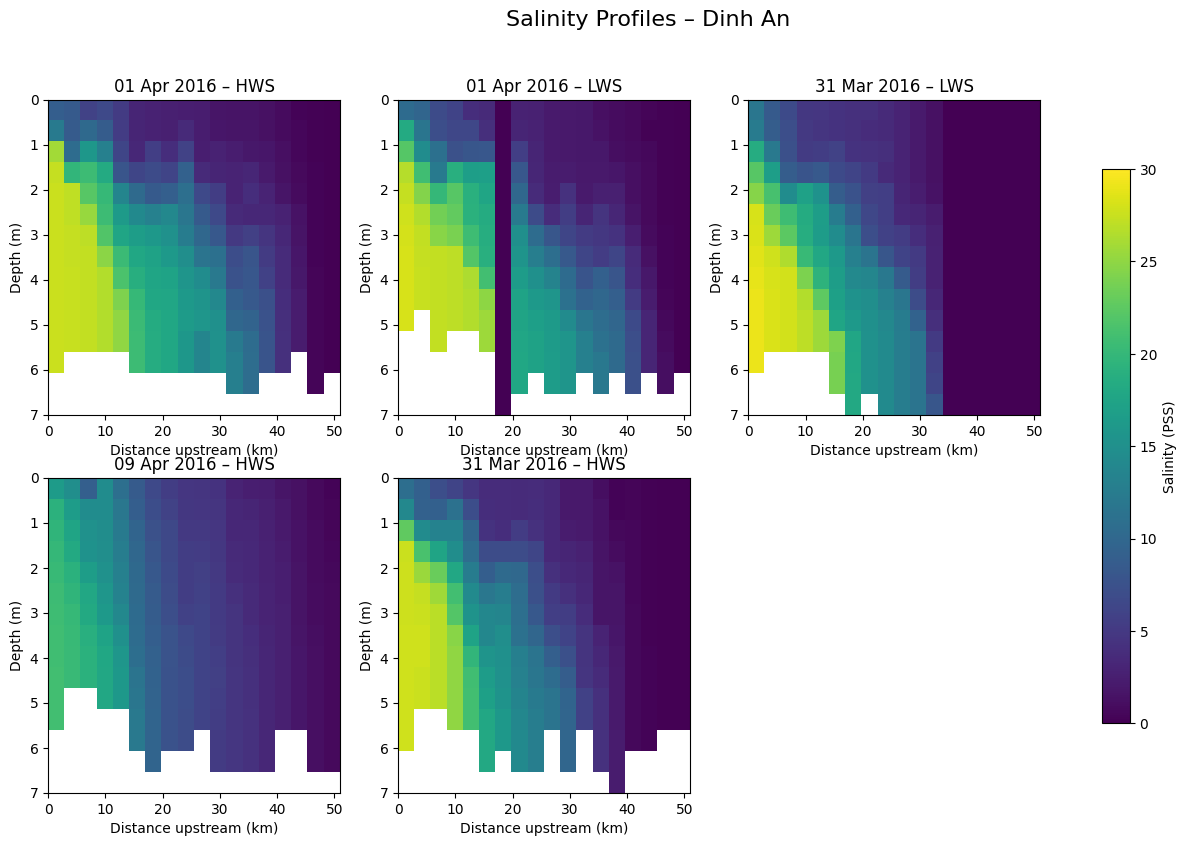

In [76]:
plot_location(dinh_an_files, "Dinh An")

Subplots for Tran De

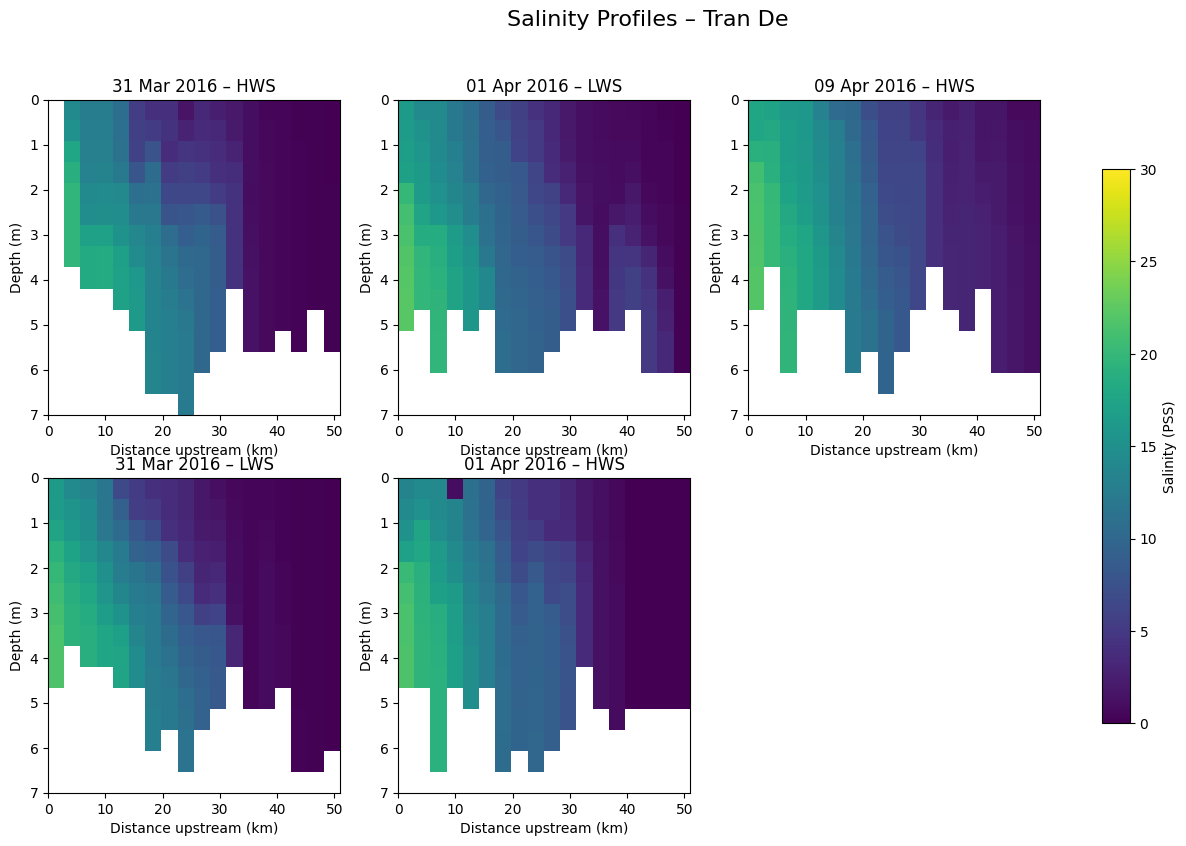

In [77]:
plot_location(tran_de_files, "Tran De")

The below analysis wants to look at how far the salinity level gets to at each measuring depth given a threshold of 0.5 PSS

In [78]:
salinity_threshold = 0.5

penetration_results = []

for file_path in csv_files:

    df = pd.read_csv(file_path)

    parts = file_path.stem.split("_")

    location_code = parts[2]

    if location_code == "da":
        location = "Dinh An"
    elif location_code == "td":
        location = "Tran De"

    for depth in df["depth_m"].unique():

        depth_data = df[df["depth_m"] == depth]

        above_threshold = depth_data[
            depth_data["salinity_pss"] >= salinity_threshold
        ]

        if not above_threshold.empty:
            max_distance = above_threshold["distance_km"].max()
        else:
            max_distance = None

        penetration_results.append({
            "location": location,
            "depth_m": depth,
            "penetration_distance_km": max_distance
        })

penetration_df = pd.DataFrame(penetration_results)

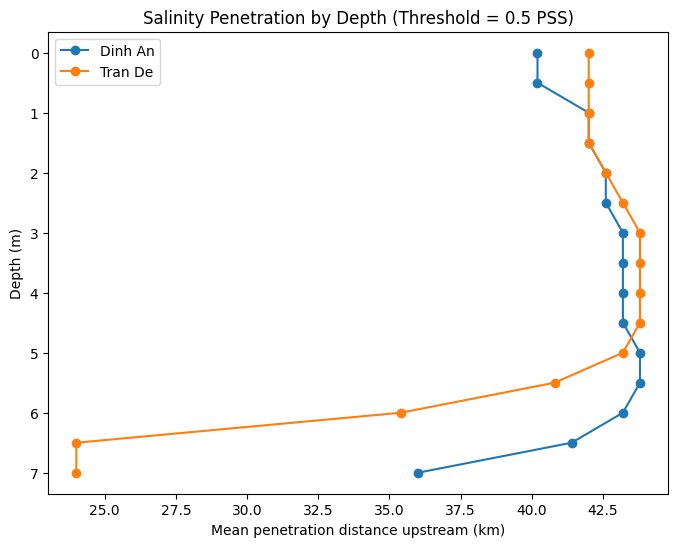

In [79]:
# Plotting the max distance vs. above threshold salinity
location_mean = (
    penetration_df
    .groupby(["location", "depth_m"])["penetration_distance_km"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 6))

for location in location_mean["location"].unique():

    location_data = location_mean[
        location_mean["location"] == location
    ]

    plt.plot(
        location_data["penetration_distance_km"],
        location_data["depth_m"],
        marker="o",
        label=location
    )

plt.gca().invert_yaxis()

plt.xlabel("Mean penetration distance upstream (km)")
plt.ylabel("Depth (m)")
plt.title("Salinity Penetration by Depth (Threshold = 0.5 PSS)")
plt.legend()

plt.show()

Cell below calculates the maximum observed distance where salinity is greater than 0.5 PSS

In [80]:
# Check maximum distance where salinity was actually measured at each depth

observation_results = []

for file_path in csv_files:

    df = pd.read_csv(file_path)

    # Get location from filename
    parts = file_path.stem.split("_")
    location_code = parts[2]

    if location_code == "da":
        location = "Dinh An"
    elif location_code == "td":
        location = "Tran De"

    for depth in df["depth_m"].unique():

        depth_data = df[df["depth_m"] == depth]

        # Remove locations where salinity was not measured
        valid_data = depth_data.dropna(subset=["salinity_pss"])

        if not valid_data.empty:
            max_observed_distance = valid_data["distance_km"].max()
        else:
            max_observed_distance = None

        observation_results.append({
            "location": location,
            "depth_m": depth,
            "max_observed_distance_km": max_observed_distance
        })

observation_df = pd.DataFrame(observation_results)

observation_mean = (
    observation_df
    .groupby(["location", "depth_m"])["max_observed_distance_km"]
    .mean()
    .reset_index()
)
 # compare max observed distance 2 locations
comparison_df = location_mean.merge(
    observation_mean,
    on=["location", "depth_m"]
)

print(comparison_df)

   location  depth_m  penetration_distance_km  max_observed_distance_km
0   Dinh An      0.0                     40.2                      51.0
1   Dinh An      0.5                     40.2                      51.0
2   Dinh An      1.0                     42.0                      51.0
3   Dinh An      1.5                     42.0                      51.0
4   Dinh An      2.0                     42.6                      51.0
5   Dinh An      2.5                     42.6                      51.0
6   Dinh An      3.0                     43.2                      51.0
7   Dinh An      3.5                     43.2                      51.0
8   Dinh An      4.0                     43.2                      51.0
9   Dinh An      4.5                     43.2                      51.0
10  Dinh An      5.0                     43.8                      51.0
11  Dinh An      5.5                     43.8                      51.0
12  Dinh An      6.0                     43.2                   

Comparison between high water and low water stack measurements

In [81]:
# Find all cleaned HWS and LWS files
hws_files = list(data_folder.glob("mb_hws_*_cleaned.csv"))
lws_files = list(data_folder.glob("mb_lws_*_cleaned.csv"))

all_comparisons = []

for hws_file in hws_files:

    # Example:
    # mb_hws_da_20160401_cleaned.csv
    parts = hws_file.stem.split("_")

    location = parts[2]
    date = parts[3]

    # Construct the corresponding LWS filename
    lws_file = data_folder / f"mb_lws_{location}_{date}_cleaned.csv"

    # Skip HWS files without matching LWS
    if not lws_file.exists():
        print(f"No matching LWS file for {hws_file.name} — skipped")
        continue

    print(f"Comparing {hws_file.name} with {lws_file.name}")

    # Read matching datasets
    df_hws = pd.read_csv(hws_file)
    df_lws = pd.read_csv(lws_file)

    # Match measurements at the same depth and distance
    df_compare = pd.merge(
        df_hws,
        df_lws,
        on=["depth_m", "distance_km"],
        suffixes=("_hws", "_lws")
    )

    # Calculate HWS - LWS
    df_compare["salinity_difference"] = (
        df_compare["salinity_pss_hws"]
        - df_compare["salinity_pss_lws"]
    )

    # Add metadata
    df_compare["location"] = location
    df_compare["date"] = date

    all_comparisons.append(df_compare)


# Combine all matching comparisons
df_all = pd.concat(all_comparisons, ignore_index=True)

print(df_all.head())
print(df_all.shape)

Comparing mb_hws_da_20160401_cleaned.csv with mb_lws_da_20160401_cleaned.csv
Comparing mb_hws_td_2016033131_cleaned.csv with mb_lws_td_2016033131_cleaned.csv
No matching LWS file for mb_hws_td_20160409_cleaned.csv — skipped
Comparing mb_hws_td_20160401_cleaned.csv with mb_lws_td_20160401_cleaned.csv
No matching LWS file for mb_hws_da_20160409_cleaned.csv — skipped
Comparing mb_hws_da_2016033131_cleaned.csv with mb_lws_da_2016033131_cleaned.csv
   depth_m  distance_km  salinity_pss_hws         source_file_hws  \
0      0.0            0             9.010  mb_hws_da_20160401.txt   
1      0.5            0            12.323  mb_hws_da_20160401.txt   
2      1.0            0            25.794  mb_hws_da_20160401.txt   
3      1.5            0            27.409  mb_hws_da_20160401.txt   
4      2.0            0            27.545  mb_hws_da_20160401.txt   

   salinity_pss_lws         source_file_lws  salinity_difference location  \
0            10.523  mb_lws_da_20160401.txt               -1

In [82]:
summary = (
    df_all
    .groupby(["location", "date"])
    .agg(
        mean_hws=("salinity_pss_hws", "mean"),
        mean_lws=("salinity_pss_lws", "mean"),
        mean_difference=("salinity_difference", "mean"),
        max_difference=("salinity_difference", "max"),
        min_difference=("salinity_difference", "min")
    )
    .reset_index()
)

print(summary)

  location        date   mean_hws  mean_lws  mean_difference  max_difference  \
0       da  2016033131   8.982524  8.233740         0.693632           8.653   
1       da    20160401  10.604638  9.577476         0.505036          18.557   
2       td  2016033131   6.997523  6.807950         0.526923           4.894   
3       td    20160401   7.664140  7.783293        -0.234275           2.687   

   min_difference  
0          -6.266  
1         -10.622  
2          -3.220  
3         -11.172  


In [83]:
# Largest positive differences: HWS much saltier than LWS
largest_hws = (
    df_all
    .sort_values("salinity_difference", ascending=False)
    [["location", "date", "distance_km", "depth_m",
      "salinity_pss_hws", "salinity_pss_lws",
      "salinity_difference"]]
    .head(10)
)

print("\nLargest HWS > LWS differences:")
print(largest_hws)


# Largest negative differences: LWS much saltier than HWS
largest_lws = (
    df_all
    .sort_values("salinity_difference")
    [["location", "date", "distance_km", "depth_m",
      "salinity_pss_hws", "salinity_pss_lws",
      "salinity_difference"]]
    .head(10)
)

print("\nLargest LWS > HWS differences:")
print(largest_lws)


Largest HWS > LWS differences:
    location        date  distance_km  depth_m  salinity_pss_hws  \
102       da    20160401           18      6.0            18.555   
101       da    20160401           18      5.5            18.555   
100       da    20160401           18      5.0            18.452   
99        da    20160401           18      4.5            17.815   
98        da    20160401           18      4.0            17.624   
97        da    20160401           18      3.5            17.243   
96        da    20160401           18      3.0            16.010   
95        da    20160401           18      2.5            13.127   
843       da  2016033131            6      1.5            17.507   
844       da  2016033131            6      2.0            23.115   

     salinity_pss_lws  salinity_difference  
102            -0.002               18.557  
101            -0.002               18.557  
100            -0.002               18.454  
99             -0.002               17.